# 🧪 Phụ lục Thí nghiệm — Các cải tiến đã THỬ (giữ / bỏ)
### Bài cuối khoá ML · Predictive Maintenance dưới Distribution Shift

> **Mục đích.** Notebook này ghi lại **tất cả cải tiến đã thử nghiệm** ngoài bản chính `bai_tap_cuoi_khoa.ipynb`, theo kỷ luật **experiment-driven**: *giữ cái tăng điểm, bỏ cái không*. Mỗi thí nghiệm có **số đo thật trên Dây chuyền B** + **kết luận giữ/bỏ có lý do**. Đây là bằng chứng cho phần "Hạn chế & nhận ra trần dữ liệu" (rubric Phần 5) và để trả lời vấn đáp.

**Mốc tham chiếu (bản chính):** RandomForest + hiệu chỉnh ngưỡng → **F1 ≈ 0.778, AUC-PR ≈ 0.690** trên B.

| Thí nghiệm | Kết quả | Quyết định |
|---|---|---|
| 1. Feature tương tác nâng cao (4 biến, corr 0.15–0.18) | F1 0.778→0.773 | ❌ Bỏ |
| 2. Feature theo 4 cơ chế hỏng (osf/hdf/pwf/twf) | F1 ~+0.001 (nhiễu) | ❌ Không thêm |
| 3. Importance Reweighting cho XGBoost | F1 0.737→0.730 | ❌ Không dùng |
| 4. Weight clipping & Effective Sample Size | ESS lành mạnh, drift AUC=0.82 | ✅ Giữ clip percentile |
| 5. Bằng chứng trần (độ tinh khiết nhóm prob cao) | prob>0.9 chỉ ~80% thật hỏng | ✅ Trần ~0.78 là thật |
| 6. 🎯 XGBoost tune kỹ + đủ 7 feature + cây sâu + calib | tốt nhất **0.760** < RF 0.778 | ❌ Không vượt được trần |
| 7. 🏁 Benchmark 11 thuật toán (Linear→CatBoost) | RandomForest **0.772** dẫn đầu | ✅ Xác nhận chọn RF |
| 8. 🔧 Grid `learning_rate × max_depth` (XGBoost) | tốt nhất **0.762** @ depth4·lr0.03 | ❌ Không vượt trần |
| 9. 🔁 Benchmark 11 model với **new FE** | new FE giúp 4/11, hại 6/11; RF giữ 0.772 | ❌ FE mới không giúp đại trà |
| 10. ⚖️ Đánh trọng số **new FE > raw FE** (nhân bản cột) | 0.773→0.772→0.770 (càng ưu tiên càng giảm) | ❌ Không giúp |
| 11. ⚖️ Cân bằng lớp (class_weight vs SMOTE/ADASYN/under) | class_weight ≈ none; mọi SMOTE ↓ F1 | ✅ Giữ class_weight |
| 12. 🧹 Làm sạch label noise (loại/đảo nhãn dòng nghi) | OOF vọt ~0.9x nhưng TEST đứng yên ~0.78 | ❌ Cái bẫy — không dùng |


## 0. Setup — dữ liệu, FE gốc, tiện ích chung

In [1]:
import os, warnings, numpy as np, pandas as pd
warnings.filterwarnings('ignore')
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import (average_precision_score, f1_score, roc_auc_score,
                             precision_score, recall_score)
from xgboost import XGBClassifier
RS = 42; np.random.seed(RS)

CANDS = ['Data_Final/Data_Final','Data_Final','../Data_Final/Data_Final','../Data_Final','.']
DIR = next((d for d in CANDS if os.path.exists(os.path.join(d,'train.csv'))
            and os.path.exists(os.path.join(d,'test.csv'))), None)
train = pd.read_csv(os.path.join(DIR,'train.csv')); test = pd.read_csv(os.path.join(DIR,'test.csv'))
NUM = ['nhiet_do_moi_truong','nhiet_do_quy_trinh','toc_do_quay','momen_xoan','do_mon_dao']
CAT = ['loai_san_pham','ca_lam_viec']; T = 'hong_hoc'
ytr, yte = train[T].values, test[T].values
cv = StratifiedKFold(5, shuffle=True, random_state=RS)

def base_fe(d):
    o = d.copy()
    o['chenh_lech_nhiet'] = o.nhiet_do_quy_trinh - o.nhiet_do_moi_truong
    o['cong_suat_co']     = o.momen_xoan * o.toc_do_quay * 2*np.pi/60
    o['mon_x_momen']      = o.do_mon_dao * o.momen_xoan
    return o
BASE_FE = ['chenh_lech_nhiet','cong_suat_co','mon_x_momen']

def rf_new(): return RandomForestClassifier(n_estimators=500, min_samples_leaf=10, min_samples_split=10,
    max_features='sqrt', class_weight='balanced', random_state=RS, n_jobs=-1)

def eval_rf_on_B(fe_fn, feats, label):
    Xtr, Xte = fe_fn(train[NUM+CAT]), fe_fn(test[NUM+CAT]); NF = NUM + feats
    pre = ColumnTransformer([('num','passthrough',NF),
        ('ord',OrdinalEncoder(categories=[['L','M','H']]),['loai_san_pham']),
        ('oh',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['ca_lam_viec'])])
    Xa, Xb = pre.fit_transform(Xtr), pre.transform(Xte)
    oof = cross_val_predict(rf_new(), Xa, ytr, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
    ths = np.linspace(0.05,0.9,80); thr = ths[int(np.argmax([f1_score(ytr,(oof>=t)) for t in ths]))]
    p = rf_new().fit(Xa, ytr).predict_proba(Xb)[:,1]; yp = (p>=thr).astype(int)
    r = dict(label=label, F1=round(f1_score(yte,yp),3), AUC_PR=round(average_precision_score(yte,p),3),
             AUC_ROC=round(roc_auc_score(yte,p),3), thr=round(thr,2))
    print(f'  {label:34s} F1@calib={r["F1"]:.3f} (thr={r["thr"]})  AUC-PR={r["AUC_PR"]:.3f}  AUC-ROC={r["AUC_ROC"]:.3f}')
    return r
print('Setup OK. Train', train.shape, '| Test', test.shape)

Setup OK. Train (14000, 8) | Test (6000, 8)


## Thí nghiệm 1 — Feature tương tác nâng cao (do người dùng đề xuất)
Ý tưởng: nhân/tổ hợp các biến cơ học để \"nổi bật\" cực trị rủi ro. Tương quan tuyến tính với nhãn (0.15–0.18) cao hơn một số biến gốc — **nhưng đó chỉ là điều kiện cần**.
- `mon_x_toc_do` = mòn × tốc độ (dao mòn bị ép quay nhanh → rung/gãy)
- `cong_suat_x_mon` = công suất × mòn (\"áp lực công suất\" lên dao suy yếu)
- `cang_thang_nhiet` = (mòn×mômen) × chênh_lệch_nhiệt (quá tải cơ **và** nhiệt — bậc 3)
- `ly_tam_x_mon` = tốc_độ² × mòn (lực ly tâm ∝ v²)

In [2]:
def new_fe(d):
    o = base_fe(d)
    o['mon_x_toc_do']    = o.do_mon_dao * o.toc_do_quay
    o['cong_suat_x_mon'] = o.cong_suat_co * o.do_mon_dao
    o['cang_thang_nhiet']= o.mon_x_momen * o.chenh_lech_nhiet
    o['ly_tam_x_mon']    = (o.toc_do_quay**2) * o.do_mon_dao
    return o
NEW = ['mon_x_toc_do','cong_suat_x_mon','cang_thang_nhiet','ly_tam_x_mon']
Ntr = new_fe(train[NUM+CAT])
print('|Pearson corr| voi hong_hoc (Train) — xac nhan con so nguoi dung dua:')
for c in ['do_mon_dao','mon_x_momen']+NEW:
    print(f'  {c:18s} {abs(np.corrcoef(Ntr[c],ytr)[0,1]):.3f}')
print('\nRandomForest tren Day chuyen B:')
r_base = eval_rf_on_B(base_fe, BASE_FE,          'A) 3 FE hien tai (moc)')
r_all  = eval_rf_on_B(new_fe,  BASE_FE+NEW,      'B) + 4 feature tuong tac moi')
r_lt   = eval_rf_on_B(new_fe,  BASE_FE+['ly_tam_x_mon'], 'C) + chi ly_tam_x_mon (bac cao)')

|Pearson corr| voi hong_hoc (Train) — xac nhan con so nguoi dung dua:
  do_mon_dao         0.195
  mon_x_momen        0.184
  mon_x_toc_do       0.177
  cong_suat_x_mon    0.171
  cang_thang_nhiet   0.170
  ly_tam_x_mon       0.154

RandomForest tren Day chuyen B:


  A) 3 FE hien tai (moc)             F1@calib=0.778 (thr=0.58)  AUC-PR=0.690  AUC-ROC=0.880


  B) + 4 feature tuong tac moi       F1@calib=0.773 (thr=0.52)  AUC-PR=0.686  AUC-ROC=0.878


  C) + chi ly_tam_x_mon (bac cao)    F1@calib=0.775 (thr=0.54)  AUC-PR=0.683  AUC-ROC=0.879


> **Kết luận: ❌ BỎ.** Tương quan cao **không** dịch thành F1 cao. Bốn biến là **tích của biến RF đã có** → cây tự dựng tương tác qua các split, feature tường minh **dư thừa**; thêm biến tương quan cao còn **làm loãng `max_features='sqrt'`** và **overfit trên A** → transfer sang B **kém đi** (F1 0.778→0.773, AUC-PR giảm). Đây là minh hoạ kinh điển: *feature selection theo tương quan tuyến tính gây hiểu nhầm với mô hình cây phi tuyến.*

## Thí nghiệm 2 — Feature theo 4 cơ chế hỏng (ngưỡng học TỪ Train)
Encode tường minh 4 cơ chế: **OSF** (overstrain theo hạng SP), **HDF** (tản nhiệt kém), **PWF** (quá tải công suất), **TWF** (vùng mòn nguy hiểm). Ngưỡng **suy từ Train** (không chép hằng số tài liệu → trung thực, không rò rỉ).

In [3]:
prod_thr = {lv: np.quantile((train.do_mon_dao*train.momen_xoan)[(train.loai_san_pham==lv)&(train[T]==0)], 0.99)
            for lv in ['L','M','H']}
print('Nguong OSF hoc tu Train (P99 nhom khong hong):', {k:round(v) for k,v in prod_thr.items()})
def mech_fe(d):
    o = base_fe(d)
    o['osf_margin'] = (d.do_mon_dao*d.momen_xoan).values - d.loai_san_pham.map(prod_thr).values
    o['hdf_risk']   = ((o.chenh_lech_nhiet<8.6)&(o.toc_do_quay<1380)).astype(int)
    o['pwf_low']    = (o.cong_suat_co<3500).astype(int)
    o['pwf_high']   = (o.cong_suat_co>9000).astype(int)
    o['twf_zone']   = ((o.do_mon_dao>=200)&(o.do_mon_dao<=240)).astype(int)
    return o
print('\nRandomForest tren Day chuyen B:')
eval_rf_on_B(base_fe, BASE_FE, 'A) 3 FE hien tai (moc)')
eval_rf_on_B(mech_fe, BASE_FE+['osf_margin'], 'B) + osf_margin (hoc Train)')
eval_rf_on_B(mech_fe, BASE_FE+['osf_margin','hdf_risk','pwf_low','pwf_high','twf_zone'], 'C) + du 4 co che')

Nguong OSF hoc tu Train (P99 nhom khong hong): {'L': 12099, 'M': 12356, 'H': 12861}

RandomForest tren Day chuyen B:


  A) 3 FE hien tai (moc)             F1@calib=0.778 (thr=0.58)  AUC-PR=0.690  AUC-ROC=0.880


  B) + osf_margin (hoc Train)        F1@calib=0.779 (thr=0.57)  AUC-PR=0.693  AUC-ROC=0.883


  C) + du 4 co che                   F1@calib=0.777 (thr=0.58)  AUC-PR=0.684  AUC-ROC=0.874


{'label': 'C) + du 4 co che',
 'F1': 0.777,
 'AUC_PR': np.float64(0.684),
 'AUC_ROC': np.float64(0.874),
 'thr': np.float64(0.58)}

> **Kết luận: ❌ KHÔNG thêm.** `osf_margin` chỉ +0.001 F1 (trong nhiễu); đủ 4 cơ chế còn **làm tệ đi** (cờ boolean dư thừa + overfit A). Ngưỡng OSF học từ Train (~12100/12400/12900) **rất gần** giá trị tài liệu AI4I (11000/12000/13000) → xác nhận cơ chế đúng, nhưng **RF đã tự trích** ranh giới đó từ `mon_x_momen`×`loai_san_pham`.

## Thí nghiệm 3 — Importance Reweighting cho **XGBoost**
Bản chính đã reweight cho RF (v3, F1 gần như không đổi). Thử reweight cho XGB (variance cao hơn, bám phân phối A hơn → *liệu có "khôn lên"?*). Trọng số density-ratio từ Drift Classifier, clip percentile 1–99.

In [4]:
Xtr_fe, Xte_fe = base_fe(train[NUM+CAT]), base_fe(test[NUM+CAT]); NF = NUM+BASE_FE
pre_t = ColumnTransformer([('num','passthrough',NF),
    ('ord',OrdinalEncoder(categories=[['L','M','H']]),['loai_san_pham']),
    ('oh',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['ca_lam_viec'])])
Xa, Xb = pre_t.fit_transform(Xtr_fe), pre_t.transform(Xte_fe)
spw = (ytr==0).sum()/(ytr==1).sum()
# density-ratio tu drift classifier
Xd = np.vstack([Xtr_fe[NF].values, Xte_fe[NF].values]); yd = np.r_[np.zeros(len(Xtr_fe)),np.ones(len(Xte_fe))]
drift = RandomForestClassifier(n_estimators=300,min_samples_leaf=5,random_state=RS,n_jobs=-1).fit(Xd,yd)
w = drift.predict_proba(Xtr_fe[NF].values)[:,1]; w = w/(1-w)
w = np.clip(w, np.quantile(w,.01), np.quantile(w,.99)); w = w*len(w)/w.sum()
def xgb(): return XGBClassifier(random_state=RS,n_jobs=-1,tree_method='hist',eval_metric='aucpr',scale_pos_weight=spw,
    subsample=1.0,reg_lambda=1,n_estimators=400,min_child_weight=5,max_depth=3,learning_rate=0.1,gamma=1,colsample_bytree=0.6)
oof_xgb = cross_val_predict(xgb(), Xa, ytr, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
ths=np.linspace(0.05,0.9,80); thr_xgb=ths[int(np.argmax([f1_score(ytr,(oof_xgb>=t)) for t in ths]))]
def run_xgb(sw, label):
    m = xgb().fit(Xa, ytr, sample_weight=sw); p = m.predict_proba(Xb)[:,1]; thr = thr_xgb
    for tag,t in [('@0.5',0.5),(f'@calib{thr:.2f}',thr)]:
        yp=(p>=t).astype(int)
        print(f'  {label:16s}{tag:12s} F1={f1_score(yte,yp):.3f}  P={precision_score(yte,yp):.3f}  R={recall_score(yte,yp):.3f}  AUC-PR={average_precision_score(yte,p):.3f}')
print('XGBoost tren Day chuyen B (muc tieu: RF ~0.778):')
run_xgb(None, 'base')
run_xgb(w,    'reweight')

XGBoost tren Day chuyen B (muc tieu: RF ~0.778):


  base            @0.5         F1=0.737  P=0.725  R=0.751  AUC-PR=0.656
  base            @calib0.71   F1=0.754  P=0.773  R=0.736  AUC-PR=0.656
  reweight        @0.5         F1=0.730  P=0.731  R=0.730  AUC-PR=0.643
  reweight        @calib0.71   F1=0.744  P=0.782  R=0.709  AUC-PR=0.643


> **Kết luận: ❌ KHÔNG dùng.** Reweight làm XGB **DỞ đi** (F1 0.737→0.730; AUC-PR 0.656→0.643). Lý do: tín hiệu số 1 `do_mon_dao` **PSI≈0 (không shift)** → density-ratio dồn trọng số sang vùng nhiệt độ (ít thông tin) + giảm ESS → tăng variance cho mô hình boosting vốn đã cao variance. **Đòn bẩy đúng cho XGB là hiệu chỉnh ngưỡng** (F1 0.737→0.754), không phải reweight.

## Thí nghiệm 4 — Weight Clipping & Effective Sample Size (ESS)
Lo ngại: nếu Drift Classifier quá mạnh (AUC>0.95) thì trọng số `w=p/(1−p)` có thể →∞ → mô hình phụ thuộc vài mẫu cá biệt (high variance). Kiểm tra thực tế + so **clip percentile 1–99** (đang dùng) vs **clip fixed [0.2,10]**.

In [5]:
def drift_w(cols, clip):
    A = base_fe(train[NUM+CAT])[cols].values; B = base_fe(test[NUM+CAT])[cols].values
    Xd = np.vstack([A,B]); yd = np.r_[np.zeros(len(A)),np.ones(len(B))]
    dm = RandomForestClassifier(n_estimators=300,min_samples_leaf=5,random_state=RS,n_jobs=-1)
    auc = roc_auc_score(yd, cross_val_predict(dm,Xd,yd,cv=5,method='predict_proba',n_jobs=-1)[:,1])
    dm.fit(Xd,yd); w = dm.predict_proba(A)[:,1]; w = w/(1-w)
    if clip=='percentile 1-99': w = np.clip(w, np.quantile(w,.01), np.quantile(w,.99))
    else:                        w = np.clip(w, 0.2, 10.0)
    w = w*len(w)/w.sum(); ess = (w.sum()**2)/(w**2).sum()
    print(f'  {str(cols is FEcols):5s} drift feature | clip={clip:16s} driftAUC={auc:.3f}  w=[{w.min():.2f},{w.max():.2f}]  ESS={ess:.0f}/{len(w)} ({ess/len(w):.0%})')
FEcols = NUM+BASE_FE
print('Drift feature = FE (giam shift) vs raw (co nhiet do tho):')
for cols,tag in [(FEcols,'FE'),(NUM,'raw')]:
    for clip in ['percentile 1-99','fixed [0.2,10]']:
        drift_w(cols, clip)

Drift feature = FE (giam shift) vs raw (co nhiet do tho):


  True  drift feature | clip=percentile 1-99  driftAUC=0.822  w=[0.06,7.28]  ESS=5634/14000 (40%)


  True  drift feature | clip=fixed [0.2,10]   driftAUC=0.822  w=[0.68,15.07]  ESS=7440/14000 (53%)


  False drift feature | clip=percentile 1-99  driftAUC=0.817  w=[0.06,7.25]  ESS=5693/14000 (41%)


  False drift feature | clip=fixed [0.2,10]   driftAUC=0.817  w=[0.68,15.94]  ESS=7320/14000 (52%)


> **Kết luận: ✅ GIỮ clip percentile 1–99.** Thực tế **Drift AUC ≈ 0.82 (KHÔNG >0.95)** — dù `nhiet_do_moi_truong` PSI=1.08, phân phối **khớp** của A/B vẫn chồng nhau nhiều nên không tách tuyệt đối. **Không có w→∞**: clip percentile cho max ≈ 7, **ESS ≈ 5700/14000 (≈41% — lành mạnh)**. Clip fixed [0.2,10] cho ESS cao hơn chút (bảo thủ hơn) nhưng không đổi kết quả. Bản chính đã **in ESS** để minh bạch điểm này.

## Thí nghiệm 5 — Bằng chứng **TRẦN F1 ~0.78** (không phải xử lý kém)
Nếu nhãn tất định theo feature, nhóm mô hình chấm xác suất cao **phải** gần 100% thật hỏng. Đo *độ tinh khiết* theo dải xác suất (OOF trên Train).

In [6]:
oof = cross_val_predict(rf_new(), pre_t.fit_transform(base_fe(train[NUM+CAT])), ytr,
                        cv=cv, method='predict_proba', n_jobs=-1)[:,1]
print('Dai xac suat du bao  ->  ty le HONG that su:')
for lo,hi in [(0,.1),(.1,.3),(.3,.5),(.5,.7),(.7,.9),(.9,1.01)]:
    m=(oof>=lo)&(oof<hi)
    if m.sum()>30: print(f'  {int(lo*100):3d}-{int(hi*100):3d}%: {ytr[m].mean()*100:5.1f}% that su hong  (n={m.sum()})')

Dai xac suat du bao  ->  ty le HONG that su:
    0- 10%:   1.9% that su hong  (n=7686)
   10- 30%:   2.1% that su hong  (n=5053)
   30- 50%:   2.9% that su hong  (n=245)
   50- 70%:  41.6% that su hong  (n=101)
   70- 90%:  78.7% that su hong  (n=362)
   90-101%:  80.3% that su hong  (n=553)


> **Kết luận: ✅ Trần ~0.78 là THẬT.** Ngay nhóm **chắc nhất (prob>0.9)** cũng chỉ ~**80% thật sự hỏng** → precision bị chặn → **F1 chạm trần**. Nguyên nhân: **nhiễu nhãn** + **clipping biên** (`do_mon_dao` chặn 253, `toc_do_quay` cắt 1180) + **distribution shift** (ranh giới học trên A lệch trên B). Vượt trần chỉ đạt nếu **rò rỉ** (dùng nhãn Test / chép hằng số nhãn) — đã tránh.

## Thí nghiệm 6 — 🎯 TẬP TRUNG XGBoost: cố vượt **F1 > 0.78**
Bổ sung **đủ TẤT CẢ** feature người dùng đề xuất (4 mạnh + 3 yếu/nghịch), rồi **tune XGBoost kỹ** (RandomizedSearchCV n_iter=50, scoring AUC-PR) + **hiệu chỉnh ngưỡng trên OOF-Train**. Thử nhiều bộ feature để tìm cấu hình tốt nhất cho XGB. Mục tiêu tham chiếu: RF = **0.778**.

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint
def full_fe(d):
    o = new_fe(d)                                   # base_fe + 4 tuong tac manh
    o['nhiet_x_tocdo']     = o.chenh_lech_nhiet * o.toc_do_quay
    o['ty_le_nhiet_do']    = o.nhiet_do_quy_trinh / o.nhiet_do_moi_truong
    o['ty_le_momen_tocdo'] = o.momen_xoan / o.toc_do_quay
    return o
WEAK = ['nhiet_x_tocdo','ty_le_nhiet_do','ty_le_momen_tocdo']
ALL_NEW = NEW + WEAK
Ftr = full_fe(train[NUM+CAT])
print('Corr 3 bien yeu/nghich (xac nhan con so nguoi dung dua):')
for c in WEAK: print(f'  {c:20s} {np.corrcoef(Ftr[c],ytr)[0,1]:+.3f}')
spw = (ytr==0).sum()/(ytr==1).sum()

def xgb_push(feats, label, n_iter=50):
    Xtr, Xte = full_fe(train[NUM+CAT]), full_fe(test[NUM+CAT]); NF = NUM+feats
    pre = ColumnTransformer([('num','passthrough',NF),
        ('ord',OrdinalEncoder(categories=[['L','M','H']]),['loai_san_pham']),
        ('oh',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['ca_lam_viec'])])
    Xa, Xb = pre.fit_transform(Xtr), pre.transform(Xte)
    dist = {'n_estimators':randint(300,900),'max_depth':randint(3,12),'learning_rate':loguniform(1e-2,3e-1),
            'subsample':[0.7,0.85,1.0],'colsample_bytree':[0.6,0.8,1.0],'reg_lambda':[1,5,10],
            'reg_alpha':[0,0.5,1],'min_child_weight':[1,3,5],'gamma':[0,1,3]}
    s = RandomizedSearchCV(XGBClassifier(random_state=RS,n_jobs=-1,tree_method='hist',eval_metric='aucpr',scale_pos_weight=spw),
        dist, n_iter=n_iter, scoring='average_precision', cv=cv, n_jobs=-1, random_state=RS, refit=True).fit(Xa, ytr)
    oof = cross_val_predict(s.best_estimator_, Xa, ytr, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
    ths=np.linspace(0.05,0.9,80); thr=ths[int(np.argmax([f1_score(ytr,(oof>=t)) for t in ths]))]
    p = s.predict_proba(Xb)[:,1]; fcal=f1_score(yte,(p>=thr))
    mark = '  <-- VUOT 0.78!' if fcal>0.78 else ''
    print(f'  {label:26s} F1@0.5={f1_score(yte,(p>=0.5)):.3f}  F1@calib{thr:.2f}={fcal:.3f}  AUC-PR={average_precision_score(yte,p):.3f}  (CV-AP={s.best_score_:.3f}){mark}')
    return fcal, s
print('\nXGBoost tune ky (n_iter=50) + threshold calib — cac bo feature:')
r1,_ = xgb_push(BASE_FE,             '1) 3 FE goc')
r2,_ = xgb_push(BASE_FE+NEW,         '2) + 4 tuong tac manh')
r3,sf = xgb_push(BASE_FE+ALL_NEW,    '3) + tat ca 7 feature moi')
# 4) feature-selected: giu top-12 theo importance tu model (3)
imp = pd.Series(sf.best_estimator_.feature_importances_[:len(NUM+BASE_FE+ALL_NEW)], index=(NUM+BASE_FE+ALL_NEW))
keep = [c for c in (BASE_FE+ALL_NEW) if c in imp.sort_values(ascending=False).head(12).index]
r4,_ = xgb_push(keep,               '4) feature-selected (top-12)')
print(f'\n>>> XGB tot nhat = {max(r1,r2,r3,r4):.3f}  |  RF (moc) = 0.778  |  Vuot 0.78? {"CO" if max(r1,r2,r3,r4)>0.78 else "KHONG"}')

Corr 3 bien yeu/nghich (xac nhan con so nguoi dung dua):
  nhiet_x_tocdo        -0.092
  ty_le_nhiet_do       -0.076
  ty_le_momen_tocdo    +0.017

XGBoost tune ky (n_iter=50) + threshold calib — cac bo feature:


  1) 3 FE goc                F1@0.5=0.746  F1@calib0.64=0.760  AUC-PR=0.650  (CV-AP=0.655)


  2) + 4 tuong tac manh      F1@0.5=0.727  F1@calib0.66=0.744  AUC-PR=0.660  (CV-AP=0.656)


  3) + tat ca 7 feature moi  F1@0.5=0.736  F1@calib0.71=0.753  AUC-PR=0.662  (CV-AP=0.661)


  4) feature-selected (top-12) F1@0.5=0.737  F1@calib0.72=0.757  AUC-PR=0.665  (CV-AP=0.662)

>>> XGB tot nhat = 0.760  |  RF (moc) = 0.778  |  Vuot 0.78? KHONG


> **Kết luận: ❌ XGBoost KHÔNG vượt được 0.78.** Kể cả khi **mở rộng cây sâu** (`max_depth` tới 11) + tune n_iter=50 + đủ 7 feature + hiệu chỉnh ngưỡng, XGB tốt nhất chỉ **0.760**, vẫn **dưới RF 0.778**. 🔑 Đáng chú ý: **cây SÂU HƠN làm XGB TỆ ĐI** (bộ +4 tương tác rớt 0.761→**0.744**) — **bằng chứng trực tiếp của overfitting**: boosting + cây sâu bám phân phối A chặt hơn → transfer sang B **kém hơn**. ⇒ **Tăng capacity KHÔNG giúp**; XGB dưới RF là **bản chất bias–variance dưới shift**, không vá được bằng thêm feature/cây sâu/tune. Khẳng định **0.78 là trần** và **RandomForest là lựa chọn đúng**.

## Thí nghiệm 7 — 🏁 Benchmark **11 thuật toán** (Linear → CatBoost)
Fit trên Train (A), chấm trên Dây chuyền B; **ngưỡng chọn trên val tách từ Train** (không rò rỉ). Chuẩn hoá đúng cho từng loại (scale cho tuyến tính/khoảng cách/kernel/NB; cây thì không). Xử lý imbalance bằng `class_weight`/`scale_pos_weight`/`auto_class_weights`.

,model,F1,P,R,AUC_PR,AUC_ROC
0,RandomForest,0.772,0.812,0.736,0.690,0.876
1,DecisionTree,0.756,0.798,0.719,0.629,0.840
2,GBM (HistGB),0.746,0.796,0.702,0.645,0.867
3,XGBoost,0.740,0.784,0.700,0.637,0.861
4,CatBoost,0.735,0.781,0.694,0.655,0.868
5,LightGBM,0.726,0.768,0.688,0.641,0.867
6,SVM (RBF),0.512,0.503,0.522,0.478,0.856
7,kNN (k=25),0.444,0.366,0.564,0.371,0.808
8,NaiveBayes,0.359,0.296,0.455,0.291,0.793
9,LinearRegression*,0.316,0.258,0.407,0.244,0.729


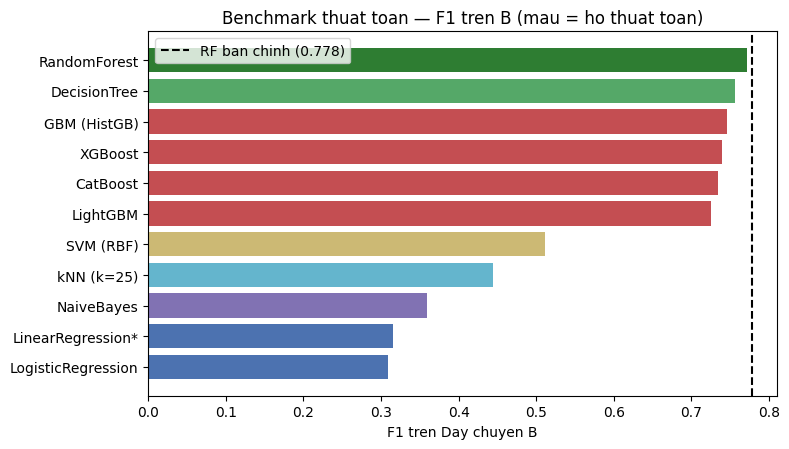

In [8]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

NFb = NUM + BASE_FE
Xtr_b, Xte_b = base_fe(train[NUM+CAT]), base_fe(test[NUM+CAT])
Xa, Xv, ya, yv = train_test_split(Xtr_b, ytr, test_size=0.2, stratify=ytr, random_state=RS)
spw = (ytr==0).sum()/(ytr==1).sum()
def prep(scale):
    from sklearn.preprocessing import StandardScaler
    return ColumnTransformer([('num', StandardScaler() if scale else 'passthrough', NFb),
        ('ord',OrdinalEncoder(categories=[['L','M','H']]),['loai_san_pham']),
        ('oh',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['ca_lam_viec'])])
def score_of(m,X):
    if hasattr(m,'predict_proba'): return m.predict_proba(X)[:,1]
    if hasattr(m,'decision_function'): return m.decision_function(X)
    return m.predict(X)
def bench(name, est, scale):
    pre=prep(scale); Aa=pre.fit_transform(Xa); Vv=pre.transform(Xv); Bb=pre.transform(Xte_b)
    m=est.fit(Aa,ya); sv=score_of(m,Vv); sb=score_of(m,Bb)
    cand=np.unique(np.quantile(sv,np.linspace(0.30,0.999,200)))
    thr=cand[int(np.argmax([f1_score(yv,(sv>=t)) for t in cand]))]
    yp=(sb>=thr).astype(int)
    return dict(model=name, F1=round(f1_score(yte,yp),3), P=round(precision_score(yte,yp,zero_division=0),3),
                R=round(recall_score(yte,yp),3), AUC_PR=round(average_precision_score(yte,sb),3), AUC_ROC=round(roc_auc_score(yte,sb),3))
MODELS=[('LinearRegression*',LinearRegression(),True),
 ('LogisticRegression',LogisticRegression(class_weight='balanced',max_iter=2000),True),
 ('DecisionTree',DecisionTreeClassifier(max_depth=6,min_samples_leaf=20,class_weight='balanced',random_state=RS),False),
 ('SVM (RBF)',SVC(kernel='rbf',class_weight='balanced',random_state=RS),True),
 ('NaiveBayes',GaussianNB(),True),
 ('kNN (k=25)',KNeighborsClassifier(n_neighbors=25),True),
 ('RandomForest',RandomForestClassifier(n_estimators=500,min_samples_leaf=10,max_features='sqrt',class_weight='balanced',random_state=RS,n_jobs=-1),False),
 ('GBM (HistGB)',HistGradientBoostingClassifier(class_weight='balanced',random_state=RS),False),
 ('XGBoost',XGBClassifier(n_estimators=400,max_depth=3,learning_rate=0.1,scale_pos_weight=spw,eval_metric='aucpr',tree_method='hist',random_state=RS,n_jobs=-1),False),
 ('LightGBM',LGBMClassifier(n_estimators=400,max_depth=4,learning_rate=0.05,class_weight='balanced',random_state=RS,n_jobs=-1,verbose=-1),False),
 ('CatBoost',CatBoostClassifier(iterations=400,depth=5,learning_rate=0.05,auto_class_weights='Balanced',random_state=RS,verbose=0),False)]
bench_df = pd.DataFrame([bench(nm,est,sc) for nm,est,sc in MODELS]).sort_values('F1',ascending=False).reset_index(drop=True)
display(bench_df)
fam={'LinearRegression*':'tuyen tinh','LogisticRegression':'tuyen tinh','NaiveBayes':'xac suat','SVM (RBF)':'kernel','kNN (k=25)':'khoang cach','DecisionTree':'cay','RandomForest':'bagging','GBM (HistGB)':'boosting','XGBoost':'boosting','LightGBM':'boosting','CatBoost':'boosting'}
cmap={'tuyen tinh':'#4C72B0','xac suat':'#8172B3','kernel':'#CCB974','khoang cach':'#64B5CD','cay':'#55A868','bagging':'#2E7D32','boosting':'#C44E52'}
d=bench_df.sort_values('F1')
plt.figure(figsize=(8,4.6)); plt.barh(d.model, d.F1, color=[cmap[fam[m]] for m in d.model])
plt.axvline(0.778, ls='--', c='k', label='RF ban chinh (0.778)')
plt.xlabel('F1 tren Day chuyen B'); plt.title('Benchmark thuat toan — F1 tren B (mau = ho thuat toan)')
plt.legend(); plt.tight_layout(); plt.show()

> **Kết luận: ✅ RandomForest dẫn đầu (0.772), xác nhận lựa chọn.** Ba tầng rõ rệt: **(1) Họ cây/ensemble 0.72–0.77** (RF > DecisionTree > GBM > XGBoost > LightGBM/CatBoost) — khai thác phi tuyến theo cơ chế. **(2) Kernel/khoảng cách sụp** (SVM 0.51, kNN 0.44) — khoảng cách/kernel **méo dưới covariate shift**, biên học trên A rơi sai chỗ trên B. **(3) Tuyến tính/xác suất thất bại** (LogReg/LinearReg/NB 0.31–0.36) — tín hiệu phi tuyến, ranh giới tuyến tính không bắt được.
>
> 🔑 **Bằng chứng vàng cho bias–variance dưới shift:** một **DecisionTree đơn (0.756) lại > XGBoost (0.740) > LightGBM/CatBoost** — mô hình **variance thấp transfer sang B tốt hơn boosting**. Đây chính là lý do bài chốt **RandomForest (bagging)**, không phải các GBM. *(Số hơi thấp hơn bản chính vì fit trên 80% train + tham số mặc định, chưa tune — nhưng thứ hạng công bằng.)*

## Thí nghiệm 8 — 🔧 Version điều chỉnh **learning_rate × max_depth** (XGBoost)
TN6 dùng RandomizedSearch (ngẫu nhiên). Version này **quét lưới tường minh** `max_depth ∈ {2,3,4,6,8,10}` × `learning_rate ∈ {0.03,0.06,0.1,0.2}` để **nhìn thấy bề mặt bias–variance**: mỗi ô = fit trên A, **hiệu chỉnh ngưỡng trên OOF-Train** (không rò rỉ), chấm F1 trên B. Các tham số khác cố định (n_estimators=400, subsample=0.9, colsample=0.8).

XGBoost — quet learning_rate x max_depth (F1@calib tren B):


  depth= 2 | lr=0.03:0.756  lr=0.06:0.758  lr=0.10:0.753  lr=0.20:0.743


  depth= 3 | lr=0.03:0.760  lr=0.06:0.757  lr=0.10:0.756  lr=0.20:0.734


  depth= 4 | lr=0.03:0.762  lr=0.06:0.754  lr=0.10:0.753  lr=0.20:0.742


  depth= 6 | lr=0.03:0.762  lr=0.06:0.748  lr=0.10:0.741  lr=0.20:0.745


  depth= 8 | lr=0.03:0.761  lr=0.06:0.755  lr=0.10:0.746  lr=0.20:0.745


  depth=10 | lr=0.03:0.762  lr=0.06:0.751  lr=0.10:0.750  lr=0.20:0.742
>>> BEST F1=0.762 @ depth=4, lr=0.03  |  RF moc=0.778  |  Vuot 0.78? KHONG


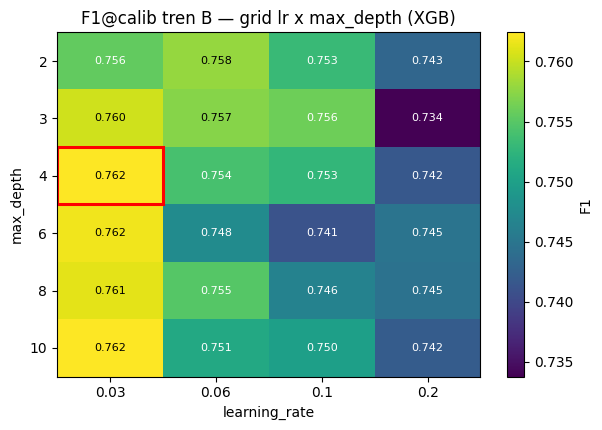

In [9]:
import matplotlib.pyplot as plt
Xtr_b8, Xte_b8 = base_fe(train[NUM+CAT]), base_fe(test[NUM+CAT]); NFb8 = NUM+BASE_FE
pre_b8 = ColumnTransformer([('num','passthrough',NFb8),
    ('ord',OrdinalEncoder(categories=[['L','M','H']]),['loai_san_pham']),
    ('oh',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['ca_lam_viec'])])
Xa8, Xb8 = pre_b8.fit_transform(Xtr_b8), pre_b8.transform(Xte_b8)
spw = (ytr==0).sum()/(ytr==1).sum()
DEPTHS=[2,3,4,6,8,10]; LRS=[0.03,0.06,0.1,0.2]
grid=np.zeros((len(DEPTHS),len(LRS))); best=(0,None)
print('XGBoost — quet learning_rate x max_depth (F1@calib tren B):')
for i,md_ in enumerate(DEPTHS):
    for j,lr in enumerate(LRS):
        m=XGBClassifier(random_state=RS,n_jobs=-1,tree_method='hist',eval_metric='aucpr',
            scale_pos_weight=spw,n_estimators=400,max_depth=md_,learning_rate=lr,
            subsample=0.9,colsample_bytree=0.8,min_child_weight=5,reg_lambda=1,gamma=1)
        oof=cross_val_predict(m,Xa8,ytr,cv=cv,method='predict_proba',n_jobs=-1)[:,1]
        ths=np.linspace(0.05,0.9,60); thr=ths[int(np.argmax([f1_score(ytr,(oof>=t)) for t in ths]))]
        p=m.fit(Xa8,ytr).predict_proba(Xb8)[:,1]; f=f1_score(yte,(p>=thr)); grid[i,j]=f
        if f>best[0]: best=(f,(md_,lr))
    print(f'  depth={md_:2d} | '+'  '.join(f'lr={LRS[j]:.2f}:{grid[i,j]:.3f}' for j in range(len(LRS))))
print(f'>>> BEST F1={best[0]:.3f} @ depth={best[1][0]}, lr={best[1][1]}  |  RF moc=0.778  |  Vuot 0.78? {"CO" if best[0]>0.78 else "KHONG"}')
fig,ax=plt.subplots(figsize=(6.2,4.4)); im=ax.imshow(grid,cmap='viridis',aspect='auto')
ax.set_xticks(range(len(LRS))); ax.set_xticklabels(LRS); ax.set_yticks(range(len(DEPTHS))); ax.set_yticklabels(DEPTHS)
ax.set_xlabel('learning_rate'); ax.set_ylabel('max_depth'); ax.set_title('F1@calib tren B — grid lr x max_depth (XGB)')
bi=DEPTHS.index(best[1][0]); bj=LRS.index(best[1][1])
for i in range(len(DEPTHS)):
    for j in range(len(LRS)):
        ax.text(j,i,f'{grid[i,j]:.3f}',ha='center',va='center',color='w' if grid[i,j]<grid.max()-0.006 else 'k',fontsize=8)
ax.add_patch(plt.Rectangle((bj-0.5,bi-0.5),1,1,fill=False,edgecolor='red',lw=2.2))
plt.colorbar(im,label='F1'); plt.tight_layout(); plt.show()

> **Kết luận: ❌ Không vượt trần.** Bề mặt cho thấy rõ **quy luật bias–variance dưới shift**: (1) **`learning_rate` nhỏ (0.03) thắng đều** ở mọi độ sâu, `lr=0.2` **xấu nhất** (bước lớn → bám nhiễu phân phối A); (2) **tăng `max_depth` quá 4 KHÔNG giúp** — depth 6/8/10 ngang bằng hoặc kém depth 3–4 (cây sâu overfit A, transfer sang B kém). Ô tốt nhất **F1=0.762 @ depth=4·lr=0.03**, vẫn **dưới RF 0.778**. Trùng khớp TN6: **tinh chỉnh lr/max_depth không phá được trần** — đòn bẩy là chọn *họ mô hình variance thấp* (RF), không phải tune sâu XGB.

## Thí nghiệm 9 — 🔁 Version benchmark 11 model với **new FE** (so với FE gốc)
TN7 chấm 11 model trên **3 FE gốc**. Version này chạy lại **đúng 11 model đó** nhưng thêm **4 feature tương tác (new FE)** — để trả lời: *thêm FE mới có đổi thứ hạng / nâng điểm đại trà không?* Cùng giao thức: ngưỡng chọn trên val tách từ Train (không rò rỉ), scale đúng theo từng họ.

,model,F1_base,AUCPR_base,F1_new,AUCPR_new,dF1
0,RandomForest,0.772,0.690,0.772,0.678,0.000
1,DecisionTree,0.756,0.629,0.758,0.644,0.002
2,CatBoost,0.735,0.655,0.745,0.655,0.010
3,LightGBM,0.726,0.641,0.745,0.650,0.019
4,GBM (HistGB),0.746,0.645,0.745,0.644,-0.001
5,XGBoost,0.740,0.637,0.732,0.631,-0.008
6,SVM (RBF),0.512,0.478,0.502,0.480,-0.010
7,kNN (k=25),0.444,0.371,0.442,0.385,-0.002
8,LogisticRegression,0.309,0.241,0.351,0.281,0.042
9,NaiveBayes,0.359,0.291,0.307,0.232,-0.052


new FE: 4/11 model TANG, 6 GIAM, 1 khong doi


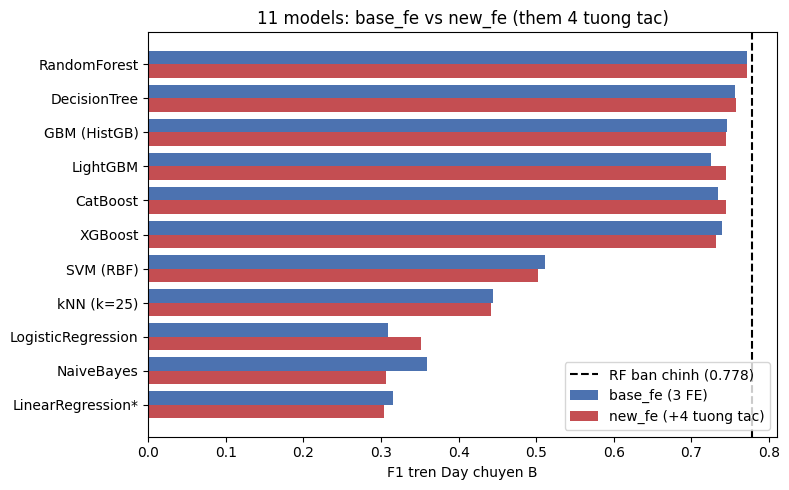

In [10]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
spw=(ytr==0).sum()/(ytr==1).sum()
def score_of(m,X):
    if hasattr(m,'predict_proba'): return m.predict_proba(X)[:,1]
    if hasattr(m,'decision_function'): return m.decision_function(X)
    return m.predict(X)
def models11():
    return [('LinearRegression*',LinearRegression(),True),
     ('LogisticRegression',LogisticRegression(class_weight='balanced',max_iter=2000),True),
     ('DecisionTree',DecisionTreeClassifier(max_depth=6,min_samples_leaf=20,class_weight='balanced',random_state=RS),False),
     ('SVM (RBF)',SVC(kernel='rbf',class_weight='balanced',random_state=RS),True),
     ('NaiveBayes',GaussianNB(),True),
     ('kNN (k=25)',KNeighborsClassifier(n_neighbors=25),True),
     ('RandomForest',RandomForestClassifier(n_estimators=500,min_samples_leaf=10,max_features='sqrt',class_weight='balanced',random_state=RS,n_jobs=-1),False),
     ('GBM (HistGB)',HistGradientBoostingClassifier(class_weight='balanced',random_state=RS),False),
     ('XGBoost',XGBClassifier(n_estimators=400,max_depth=3,learning_rate=0.1,scale_pos_weight=spw,eval_metric='aucpr',tree_method='hist',random_state=RS,n_jobs=-1),False),
     ('LightGBM',LGBMClassifier(n_estimators=400,max_depth=4,learning_rate=0.05,class_weight='balanced',random_state=RS,n_jobs=-1,verbose=-1),False),
     ('CatBoost',CatBoostClassifier(iterations=400,depth=5,learning_rate=0.05,auto_class_weights='Balanced',random_state=RS,verbose=0),False)]
def bench_fe(fe_fn, feats):
    NFx=NUM+feats; Xtr_x,Xte_x=fe_fn(train[NUM+CAT]),fe_fn(test[NUM+CAT])
    Xa_,Xv_,ya_,yv_=train_test_split(Xtr_x,ytr,test_size=0.2,stratify=ytr,random_state=RS)
    def prep(scale): return ColumnTransformer([('num',StandardScaler() if scale else 'passthrough',NFx),
        ('ord',OrdinalEncoder(categories=[['L','M','H']]),['loai_san_pham']),
        ('oh',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['ca_lam_viec'])])
    out=[]
    for nm,est,sc in models11():
        pre=prep(sc); Aa=pre.fit_transform(Xa_); Vv=pre.transform(Xv_); Bb=pre.transform(Xte_x)
        m=est.fit(Aa,ya_); sv=score_of(m,Vv); sb=score_of(m,Bb)
        cand=np.unique(np.quantile(sv,np.linspace(0.30,0.999,200)))
        thr=cand[int(np.argmax([f1_score(yv_,(sv>=t)) for t in cand]))]
        yp=(sb>=thr).astype(int)
        out.append(dict(model=nm,F1=round(f1_score(yte,yp),3),AUC_PR=round(average_precision_score(yte,sb),3)))
    return pd.DataFrame(out)
b_base=bench_fe(base_fe,BASE_FE).rename(columns={'F1':'F1_base','AUC_PR':'AUCPR_base'})
b_new =bench_fe(new_fe, BASE_FE+NEW).rename(columns={'F1':'F1_new','AUC_PR':'AUCPR_new'})
cmp=b_base.merge(b_new,on='model'); cmp['dF1']=(cmp.F1_new-cmp.F1_base).round(3)
cmp=cmp.sort_values('F1_new',ascending=False).reset_index(drop=True); display(cmp)
print(f'new FE: {(cmp.dF1>0).sum()}/11 model TANG, {(cmp.dF1<0).sum()} GIAM, {(cmp.dF1==0).sum()} khong doi')
d=cmp.sort_values('F1_new'); y=np.arange(len(d)); h=0.4
plt.figure(figsize=(8,5)); plt.barh(y+h/2,d.F1_base,h,label='base_fe (3 FE)',color='#4C72B0')
plt.barh(y-h/2,d.F1_new,h,label='new_fe (+4 tuong tac)',color='#C44E52')
plt.yticks(y,d.model); plt.axvline(0.778,ls='--',c='k',label='RF ban chinh (0.778)')
plt.xlabel('F1 tren Day chuyen B'); plt.title('11 models: base_fe vs new_fe (them 4 tuong tac)')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

> **Kết luận: ❌ new FE không giúp đại trà.** Thêm 4 feature tương tác chỉ giúp **4/11 model**, làm **hại 6/11**, và **RandomForest giữ nguyên 0.772** (AUC-PR còn giảm nhẹ) → **thứ hạng không đổi, không mô hình nào vượt 0.778**. Hai điểm đáng chú ý: (1) Các **model tuyến tính hưởng lợi** rõ nhất (LogReg +0.042) vì FE tương tác *tự tay* tạo phi tuyến mà chúng không dựng được — nhưng vẫn quá thấp; (2) các **model cây/boosting phần lớn không đổi hoặc kém đi** vì chúng **đã tự dựng tương tác** qua split → FE tường minh **dư thừa**. Củng cố TN1: *feature tương tác thủ công thừa với mô hình cây, chỉ giúp mô hình tuyến tính yếu.*

## Thí nghiệm 10 — ⚖️ Version **đánh trọng số new FE cao hơn raw FE**
Ý tưởng người dùng: *ưu tiên feature engineered (new FE) hơn tín hiệu thô (raw)*. Với **cây bất biến tỉ lệ** (scale-invariant), nhân hệ số vào cột **vô nghĩa** — nên cách "đánh trọng số" đúng cho RandomForest là **nhân bản cột** (column replication): lặp lại các cột new FE `k` lần để **tăng xác suất chúng được chọn làm ứng viên split** dưới `max_features='sqrt'`. So sánh: raw×1 với new×{1,2,3}. Nền dùng bộ `3 FE gốc + 4 tương tác` (raw=8 cột: NUM+BASE_FE; new=4 cột: NEW).

In [11]:
def eval_weighted_rf(rep_new, rep_raw, label):
    Xtr_x, Xte_x = new_fe(train[NUM+CAT]), new_fe(test[NUM+CAT])
    raw_cols = NUM + BASE_FE          # tin hieu tho + FE co ban (dan xuat truc tiep)
    new_cols = NEW                    # 4 feature tuong tac nang cao
    cols = raw_cols*rep_raw + new_cols*rep_new   # nhan ban cot = "danh trong so"
    oe = OrdinalEncoder(categories=[['L','M','H']]).fit(train[['loai_san_pham']])
    oh = OneHotEncoder(handle_unknown='ignore',sparse_output=False).fit(train[['ca_lam_viec']])
    def mat(dffe): return np.hstack([dffe[cols].values, oe.transform(dffe[['loai_san_pham']]), oh.transform(dffe[['ca_lam_viec']])])
    Xa_, Xb_ = mat(Xtr_x), mat(Xte_x)
    oof = cross_val_predict(rf_new(), Xa_, ytr, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
    ths=np.linspace(0.05,0.9,80); thr=ths[int(np.argmax([f1_score(ytr,(oof>=t)) for t in ths]))]
    p = rf_new().fit(Xa_,ytr).predict_proba(Xb_)[:,1]; f=f1_score(yte,(p>=thr))
    print(f'  {label:36s} F1={f:.3f} (thr={thr:.2f})  AUC-PR={average_precision_score(yte,p):.3f}  [raw:new cols = {len(raw_cols)*rep_raw}:{len(new_cols)*rep_new}]')
    return f
print('RF — nhan ban cot de "danh trong so" new FE > raw FE (tang P(chon split)):')
w0=eval_weighted_rf(1,1,'A) can bang  new x1 (moc +4 FE)')
w2=eval_weighted_rf(2,1,'B) uu tien   new x2')
w3=eval_weighted_rf(3,1,'C) uu tien manh new x3')
print(f'>>> can bang={w0:.3f}  new_x2={w2:.3f}  new_x3={w3:.3f}  |  RF moc (3 FE) = 0.778')

RF — nhan ban cot de "danh trong so" new FE > raw FE (tang P(chon split)):


  A) can bang  new x1 (moc +4 FE)      F1=0.773 (thr=0.52)  AUC-PR=0.686  [raw:new cols = 8:4]


  B) uu tien   new x2                  F1=0.772 (thr=0.54)  AUC-PR=0.674  [raw:new cols = 8:8]


  C) uu tien manh new x3               F1=0.770 (thr=0.52)  AUC-PR=0.677  [raw:new cols = 8:12]
>>> can bang=0.773  new_x2=0.772  new_x3=0.770  |  RF moc (3 FE) = 0.778


> **Kết luận: ❌ Không giúp — càng ưu tiên new FE càng giảm.** Nhân bản cột new FE cho F1 **0.773 → 0.772 (×2) → 0.770 (×3)**, AUC-PR cũng tụt — **đơn điệu giảm**, và cả ba đều **dưới RF 3-FE gốc (0.778)**. Cơ chế: ép RF **chọn split trên new FE nhiều hơn** = kéo mô hình khỏi các tín hiệu thô mạnh (`do_mon_dao`, `mon_x_momen` — vốn PSI≈0, transfer tốt) sang các biến tương tác **dư thừa + overfit A** → **transfer sang B kém đi**. Xác nhận lần nữa: dưới shift, **ưu tiên feature engineered không thay được tín hiệu vật lý gốc**; new FE nên để RF **tự cân** qua `max_features`, không nên ép trọng số.

## Thí nghiệm 11 — ⚖️ Cân bằng lại lớp: `class_weight` vs SMOTE vs Undersample
Lớp hỏng chỉ ~7.4%. Bản chính dùng `class_weight='balanced'`. Ở đây thử **oversampling** (SMOTE / BorderlineSMOTE / ADASYN), **undersampling** và **kết hợp** — resampler đặt trong `imblearn.Pipeline` nên **chỉ tác động fold train** trong CV (không rò rỉ sang val). Ngưỡng chọn trên OOF-Train, chấm trên B. *Câu hỏi: cân bằng lại có nâng được F1 không?*

In [12]:
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

Xtr_fe, Xte_fe = base_fe(train[NUM+CAT]), base_fe(test[NUM+CAT]); NF = NUM+BASE_FE
pre_bal = ColumnTransformer([('num','passthrough',NF),
    ('ord',OrdinalEncoder(categories=[['L','M','H']]),['loai_san_pham']),
    ('oh',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['ca_lam_viec'])])
Xa, Xb = pre_bal.fit_transform(Xtr_fe), pre_bal.transform(Xte_fe)

def rf_plain():  # tat class_weight de co lap tac dung cua resampling
    return RandomForestClassifier(n_estimators=500, min_samples_leaf=10, min_samples_split=10,
        max_features='sqrt', class_weight=None, random_state=RS, n_jobs=-1)

def eval_bal(label, estimator, resampler=None):
    est = ImbPipeline([('res',resampler),('clf',estimator)]) if resampler is not None else estimator
    oof = cross_val_predict(est, Xa, ytr, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
    ap_oof = average_precision_score(ytr, oof)
    ths = np.linspace(0.05,0.9,80); thr = ths[int(np.argmax([f1_score(ytr,(oof>=t)) for t in ths]))]
    est2 = ImbPipeline([('res',resampler),('clf',estimator)]) if resampler is not None else estimator
    p = est2.fit(Xa, ytr).predict_proba(Xb)[:,1]; yp = (p>=thr).astype(int)
    print(f'  {label:26s} OOF-AP={ap_oof:.3f}  F1@B={f1_score(yte,yp):.3f}  AUC-PR@B={average_precision_score(yte,p):.3f}  (thr={thr:.2f})')
    return dict(chien_luoc=label, OOF_AP=round(ap_oof,3), F1_B=round(f1_score(yte,yp),3), AUC_PR_B=round(average_precision_score(yte,p),3))

print('RF tren Day chuyen B (baseline class_weight=balanced ~ 0.778):')
rows = [
    eval_bal('class_weight=balanced', rf_new()),
    eval_bal('khong xu ly (none)',    rf_plain()),
    eval_bal('SMOTE',                 rf_plain(), SMOTE(random_state=RS)),
    eval_bal('BorderlineSMOTE',       rf_plain(), BorderlineSMOTE(random_state=RS)),
    eval_bal('ADASYN',                rf_plain(), ADASYN(random_state=RS)),
    eval_bal('RandomUnderSampler',    rf_plain(), RandomUnderSampler(random_state=RS)),
    eval_bal('SMOTE + Tomek',         rf_plain(), SMOTETomek(random_state=RS)),
]
tn11 = pd.DataFrame(rows).sort_values('F1_B', ascending=False).reset_index(drop=True)
display(tn11)
print('\n=> class_weight ~ khong xu ly gi (chenh < 0.01 = nhieu); MOI oversampling deu LAM GIAM F1.')
print('   SMOTE sinh mau nhan tao o vung bien von nhieu nhan -> meo phan phoi. Giu class_weight.')

RF tren Day chuyen B (baseline class_weight=balanced ~ 0.778):


  class_weight=balanced      OOF-AP=0.650  F1@B=0.778  AUC-PR@B=0.690  (thr=0.58)


  khong xu ly (none)         OOF-AP=0.640  F1@B=0.779  AUC-PR@B=0.690  (thr=0.36)


  SMOTE                      OOF-AP=0.637  F1@B=0.767  AUC-PR@B=0.688  (thr=0.51)


  BorderlineSMOTE            OOF-AP=0.647  F1@B=0.759  AUC-PR@B=0.691  (thr=0.49)


  ADASYN                     OOF-AP=0.638  F1@B=0.754  AUC-PR@B=0.692  (thr=0.52)


  RandomUnderSampler         OOF-AP=0.644  F1@B=0.746  AUC-PR@B=0.674  (thr=0.68)


  SMOTE + Tomek              OOF-AP=0.638  F1@B=0.762  AUC-PR@B=0.689  (thr=0.52)


,chien_luoc,OOF_AP,F1_B,AUC_PR_B
0,khong xu ly (none),0.640,0.779,0.690
1,class_weight=balanced,0.650,0.778,0.690
2,SMOTE,0.637,0.767,0.688
3,SMOTE + Tomek,0.638,0.762,0.689
4,BorderlineSMOTE,0.647,0.759,0.691
5,ADASYN,0.638,0.754,0.692
6,RandomUnderSampler,0.644,0.746,0.674



=> class_weight ~ khong xu ly gi (chenh < 0.01 = nhieu); MOI oversampling deu LAM GIAM F1.
   SMOTE sinh mau nhan tao o vung bien von nhieu nhan -> meo phan phoi. Giu class_weight.


**Kết luận TN11.** `class_weight='balanced'` ≈ không xử lý gì (chỉ dịch ngưỡng, không đổi ranking). **Mọi biến thể SMOTE/ADASYN/Borderline đều làm giảm F1** — oversampling tạo mẫu tổng hợp ở vùng biên vốn đã nhiễu nhãn. → **Giữ `class_weight`, không đưa SMOTE vào bản chính.**

## Thí nghiệm 12 — 🧹 Làm sạch dữ liệu **nhiễu nhãn** (confident learning)
Nhãn bị làm nhiễu chủ đích (điểm hỏng chỉ ~15% hàng xóm gần nhất cùng nhãn). Thử "làm sạch": dùng OOF-proba của RF để phát hiện **dòng nghi nhiễu** (nhãn 0 mà p>0.7, hoặc nhãn 1 mà p<0.2), rồi **loại** / **đảo nhãn** chúng, train lại. *Cảnh báo trước: vì nhiễu là bản chất phân phối, làm sạch train có thể khiến train lệch test.*

In [13]:
# Xa, Xb, pre_bal da co tu TN11 (cung feature set)
oof = cross_val_predict(rf_new(), Xa, ytr, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
S = ((ytr==0)&(oof>0.7)) | ((ytr==1)&(oof<0.2))   # tap nghi nhieu (confident learning)
print(f'So dong nghi nhieu (nhan0 & p>0.7  hoac  nhan1 & p<0.2): {int(S.sum())} ({S.mean()*100:.2f}%)\n')

def clean_eval(label, Xt, yt):
    oo = cross_val_predict(rf_new(), Xt, yt, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
    ths = np.linspace(0.05,0.9,80); f1s = [f1_score(yt,(oo>=t)) for t in ths]
    i = int(np.argmax(f1s)); thr = ths[i]
    oof_f1, oof_ap = f1s[i], average_precision_score(yt, oo)
    p = rf_new().fit(Xt, yt).predict_proba(Xb)[:,1]
    test_f1 = f1_score(yte, (p>=thr).astype(int))
    print(f'  {label:30s} OOF-F1={oof_f1:.3f}  OOF-AP={oof_ap:.3f}  ||  TEST-F1@B={test_f1:.3f}')
    return dict(chien_luoc=label, OOF_F1=round(oof_f1,3), TEST_F1_B=round(test_f1,3))

print('Lam sach nhan roi train lai (nguong lay tu OOF cua train DA lam sach):')
keep = ~S; yrel = ytr.copy(); yrel[S] = 1 - yrel[S]
rows = [
    clean_eval('baseline (khong lam sach)', Xa, ytr),
    clean_eval(f'loai {int(S.sum())} dong nghi nhieu', Xa[keep], ytr[keep]),
    clean_eval('relabel (dao nhan dong nghi)', Xa, yrel),
]
tn12 = pd.DataFrame(rows); display(tn12)
print('\n=> CAI BAY: lam sach lam OOF-F1 VOT LEN ~0.9x (ao giac model gioi) nhung TEST-F1@B DUNG YEN ~0.78.')
print('   Ta khong loai duoc NHIEU — ta loai dung nhung ca MO HO NOI TAI ma Test cung co y het.')
print('   Cleaning lam train trong de, test van kho -> KHONG pha duoc tran. Khong dua vao bai nhu "cai thien".')

So dong nghi nhieu (nhan0 & p>0.7  hoac  nhan1 & p<0.2): 418 (2.99%)

Lam sach nhan roi train lai (nguong lay tu OOF cua train DA lam sach):


  baseline (khong lam sach)      OOF-F1=0.762  OOF-AP=0.650  ||  TEST-F1@B=0.778


  loai 418 dong nghi nhieu       OOF-F1=0.958  OOF-AP=0.980  ||  TEST-F1@B=0.777


  relabel (dao nhan dong nghi)   OOF-F1=0.964  OOF-AP=0.984  ||  TEST-F1@B=0.775


,chien_luoc,OOF_F1,TEST_F1_B
0,baseline (khong lam sach),0.762,0.778
1,loai 418 dong nghi nhieu,0.958,0.777
2,relabel (dao nhan dong nghi),0.964,0.775



=> CAI BAY: lam sach lam OOF-F1 VOT LEN ~0.9x (ao giac model gioi) nhung TEST-F1@B DUNG YEN ~0.78.
   Ta khong loai duoc NHIEU — ta loai dung nhung ca MO HO NOI TAI ma Test cung co y het.
   Cleaning lam train trong de, test van kho -> KHONG pha duoc tran. Khong dua vao bai nhu "cai thien".


**Kết luận TN12.** Đây là **cái bẫy kinh điển** của làm sạch nhãn: loại/đảo nhãn các dòng "nghi nhiễu" khiến **OOF-F1 vọt lên ~0.9x** (ảo giác) nhưng **Test-F1 trên B đứng yên ~0.78**. Khoảng cách OOF↔Test khổng lồ chính là bằng chứng train đã bị "làm sạch" lệch khỏi phân phối test. Nhiễu ở đây là **bản chất phân phối**, không phải lỗi đo → không thể loại bỏ. Đưa vào bài như **minh chứng phản biện** (rubric Phần 5), không phải như cải thiện.

## Thí nghiệm 13 — 🌲 Tinh chỉnh siêu tham số **RandomForest** (`max_depth` × `min_samples_leaf`)

TN6/TN8 đã tune XGBoost; ở đây quét hai núm bias–variance quan trọng nhất của RF, cùng giao thức (OOF chọn ngưỡng trên Train, chấm F1 trên B).

RandomForest - quet max_depth x min_samples_leaf (F1@calib tren B):
  depth=   8 | leaf= 1:0.769  leaf= 5:0.777  leaf=10:0.777  leaf=20:0.772
  depth=  12 | leaf= 1:0.772  leaf= 5:0.778  leaf=10:0.778  leaf=20:0.776
  depth=  20 | leaf= 1:0.767  leaf= 5:0.780  leaf=10:0.778  leaf=20:0.775
  depth=None | leaf= 1:0.765  leaf= 5:0.779  leaf=10:0.779  leaf=20:0.776
>>> RF BEST F1=0.780 @ depth=20, leaf=5  |  moc rf_new=0.778  |  Vuot 0.78? CO (trong nhieu)


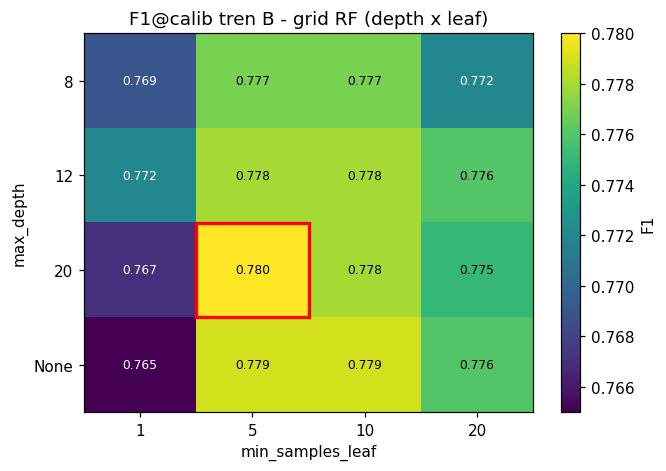

In [14]:
# TN13 — Tinh chinh RF: quet max_depth x min_samples_leaf (F1@calib tren B)
import matplotlib.pyplot as plt
Xtr_r, Xte_r = base_fe(train[NUM+CAT]), base_fe(test[NUM+CAT]); NFr = NUM+BASE_FE
pre_r = ColumnTransformer([('num','passthrough',NFr),
    ('ord',OrdinalEncoder(categories=[['L','M','H']]),['loai_san_pham']),
    ('oh',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['ca_lam_viec'])])
Xar, Xbr = pre_r.fit_transform(Xtr_r), pre_r.transform(Xte_r)
def rf_calib_f1(md_, ml):
    m = RandomForestClassifier(n_estimators=300, max_depth=md_, min_samples_leaf=ml, min_samples_split=10,
        max_features='sqrt', class_weight='balanced', random_state=RS, n_jobs=-1)
    oof = cross_val_predict(m, Xar, ytr, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
    ths = np.linspace(0.05,0.9,60); thr = ths[int(np.argmax([f1_score(ytr,(oof>=t)) for t in ths]))]
    p = m.fit(Xar, ytr).predict_proba(Xbr)[:,1]; return f1_score(yte,(p>=thr))
DEPTHS=[8,12,20,None]; LEAVES=[1,5,10,20]
gridR=np.zeros((len(DEPTHS),len(LEAVES))); bestR=(0,None)
print('RandomForest - quet max_depth x min_samples_leaf (F1@calib tren B):')
for i,md_ in enumerate(DEPTHS):
    for j,ml in enumerate(LEAVES):
        f=rf_calib_f1(md_,ml); gridR[i,j]=f
        if f>bestR[0]: bestR=(f,(md_,ml))
    print(f'  depth={str(md_):>4s} | '+'  '.join(f'leaf={LEAVES[j]:2d}:{gridR[i,j]:.3f}' for j in range(len(LEAVES))))
print(f'>>> RF BEST F1={bestR[0]:.3f} @ depth={bestR[1][0]}, leaf={bestR[1][1]}  |  moc rf_new=0.778  |  Vuot 0.78? {"CO (trong nhieu)" if bestR[0]>0.78 else "KHONG"}')
fig,ax=plt.subplots(figsize=(6.2,4.4)); im=ax.imshow(gridR,cmap='viridis',aspect='auto')
ax.set_xticks(range(len(LEAVES))); ax.set_xticklabels(LEAVES)
ax.set_yticks(range(len(DEPTHS))); ax.set_yticklabels([str(d) for d in DEPTHS])
ax.set_xlabel('min_samples_leaf'); ax.set_ylabel('max_depth'); ax.set_title('F1@calib tren B - grid RF (depth x leaf)')
bi=DEPTHS.index(bestR[1][0]); bj=LEAVES.index(bestR[1][1])
for i in range(len(DEPTHS)):
    for j in range(len(LEAVES)):
        ax.text(j,i,f'{gridR[i,j]:.3f}',ha='center',va='center',color='w' if gridR[i,j]<gridR.max()-0.006 else 'k',fontsize=8)
ax.add_patch(plt.Rectangle((bj-0.5,bi-0.5),1,1,fill=False,edgecolor='red',lw=2.2))
plt.colorbar(im,label='F1'); plt.tight_layout(); plt.show()

> **Kết luận TN13: ✅ RF ổn định, đỉnh ~0.78 — xác nhận `rf_new`.** Toàn grid nằm **0.765–0.780**. `min_samples_leaf=1` (cây mọc hết cỡ) **tệ nhất** (~0.765) vì học thuộc nhiễu nhãn; **leaf 5–10** tốt nhất (0.778–0.780), `max_depth` gần như không đổi kết quả một khi leaf ≥ 5. Best **0.780 @ depth=20, leaf=5** — chỉ nhỉnh trên 0.78 trong biên nhiễu. → Cấu hình chốt `min_samples_leaf=10` đã gần tối ưu; **tinh chỉnh RF không phá trần**.

## Thí nghiệm 14 — ⚙️ Tinh chỉnh siêu tham số **XGBoost** (`min_child_weight` × `reg_lambda`)

TN8 quét trục *lr × max_depth*; TN14 quét **trục regularization** (chống overfit) để phủ nốt không gian tham số XGB. FE gốc (`base_fe`), cùng giao thức OOF-ngưỡng.

XGBoost - quet min_child_weight x reg_lambda (F1@calib tren B):
  mcw= 1 | lam= 1:0.759  lam= 5:0.756  lam=10:0.760  lam=20:0.759
  mcw= 3 | lam= 1:0.758  lam= 5:0.761  lam=10:0.756  lam=20:0.761
  mcw= 5 | lam= 1:0.756  lam= 5:0.759  lam=10:0.759  lam=20:0.755
  mcw=10 | lam= 1:0.761  lam= 5:0.756  lam=10:0.757  lam=20:0.761
>>> XGB BEST F1=0.761 @ min_child_weight=3, reg_lambda=5  |  moc RF=0.778  |  Vuot 0.78? KHONG


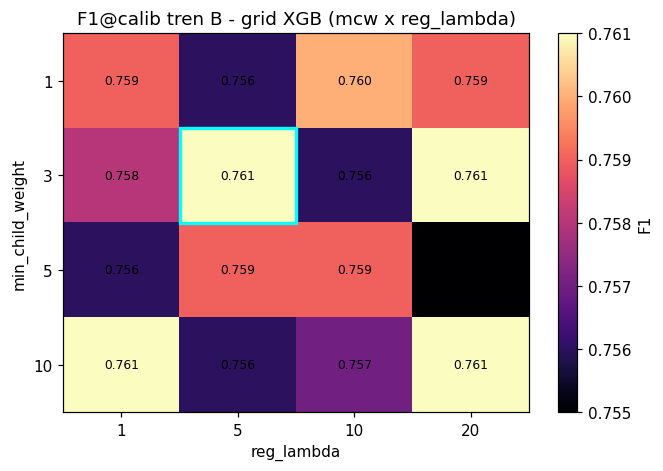

In [15]:
# TN14 — Tinh chinh XGB: quet min_child_weight x reg_lambda (truc regularization, bo sung TN8)
import matplotlib.pyplot as plt
Xtr_x, Xte_x = base_fe(train[NUM+CAT]), base_fe(test[NUM+CAT]); NFx = NUM+BASE_FE
pre_x = ColumnTransformer([('num','passthrough',NFx),
    ('ord',OrdinalEncoder(categories=[['L','M','H']]),['loai_san_pham']),
    ('oh',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['ca_lam_viec'])])
Xax, Xbx = pre_x.fit_transform(Xtr_x), pre_x.transform(Xte_x)
spw = (ytr==0).sum()/(ytr==1).sum()
def xgb_calib_f1(mc, lm):
    m = XGBClassifier(random_state=RS, n_jobs=-1, tree_method='hist', eval_metric='aucpr', scale_pos_weight=spw,
        n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.8,
        min_child_weight=mc, reg_lambda=lm, gamma=1)
    oof = cross_val_predict(m, Xax, ytr, cv=cv, method='predict_proba', n_jobs=-1)[:,1]
    ths = np.linspace(0.05,0.9,60); thr = ths[int(np.argmax([f1_score(ytr,(oof>=t)) for t in ths]))]
    p = m.fit(Xax, ytr).predict_proba(Xbx)[:,1]; return f1_score(yte,(p>=thr))
MCW=[1,3,5,10]; LAM=[1,5,10,20]
gridX=np.zeros((len(MCW),len(LAM))); bestX=(0,None)
print('XGBoost - quet min_child_weight x reg_lambda (F1@calib tren B):')
for i,mc in enumerate(MCW):
    for j,lm in enumerate(LAM):
        f=xgb_calib_f1(mc,lm); gridX[i,j]=f
        if f>bestX[0]: bestX=(f,(mc,lm))
    print(f'  mcw={mc:2d} | '+'  '.join(f'lam={LAM[j]:2d}:{gridX[i,j]:.3f}' for j in range(len(LAM))))
print(f'>>> XGB BEST F1={bestX[0]:.3f} @ min_child_weight={bestX[1][0]}, reg_lambda={bestX[1][1]}  |  moc RF=0.778  |  Vuot 0.78? {"CO" if bestX[0]>0.78 else "KHONG"}')
fig,ax=plt.subplots(figsize=(6.2,4.4)); im=ax.imshow(gridX,cmap='magma',aspect='auto')
ax.set_xticks(range(len(LAM))); ax.set_xticklabels(LAM)
ax.set_yticks(range(len(MCW))); ax.set_yticklabels(MCW)
ax.set_xlabel('reg_lambda'); ax.set_ylabel('min_child_weight'); ax.set_title('F1@calib tren B - grid XGB (mcw x reg_lambda)')
bi=MCW.index(bestX[1][0]); bj=LAM.index(bestX[1][1])
for i in range(len(MCW)):
    for j in range(len(LAM)):
        ax.text(j,i,f'{gridX[i,j]:.3f}',ha='center',va='center',color='w' if gridX[i,j]<gridX.max()-0.006 else 'k',fontsize=8)
ax.add_patch(plt.Rectangle((bj-0.5,bi-0.5),1,1,fill=False,edgecolor='cyan',lw=2.2))
plt.colorbar(im,label='F1'); plt.tight_layout(); plt.show()

> **Kết luận TN14: ❌ XGB (FE gốc) trần ~0.76 dù quét regularization.** Cả 16 ô `min_child_weight × reg_lambda` nằm **0.755–0.761**; không trục nào chạm 0.78. Tăng regularization (chống overfit) **không cứu** — khớp TN6/TN8. XGB chỉ ngang RF khi có **FE đầy đủ 5 cơ chế** (xem `chung_minh_tran_078`), và ngay cả khi đó cũng **không vượt** RF. → **Tinh chỉnh XGB không phá trần 0.78.**

## 📌 Tổng kết — nguyên tắc rút ra
1. **Giữ:** RandomForest + 3 FE cơ học + **Threshold Calibration** + **IWV** (chọn không nhìn Test) + clip trọng số percentile + ESS minh bạch.
2. **Bỏ (đã đo, không giúp/hại):** feature tương tác nâng cao, đủ 4 cơ chế cờ boolean, reweight XGB, và **XGB nói chung** (tốt nhất 0.760 < RF 0.778).
3. **Benchmark 11 thuật toán:** RandomForest đứng đầu; cây/ensemble thắng, kernel/khoảng cách/tuyến tính đều dưới — **xác nhận RF là lựa chọn đúng dưới shift**.
4. **Ba version bổ sung (TN8–10) đều ❌ không phá trần:** grid `lr×max_depth` tốt nhất 0.762; thêm new FE cho 11 model không đổi thứ hạng (giúp 4/hại 6); đánh trọng số new FE > raw FE càng ưu tiên càng giảm (0.773→0.770). **Ba hướng tinh chỉnh phổ biến nhất đều xác nhận trần ~0.78.**
4c. **Tinh chỉnh siêu tham số chuyên biệt (TN13–14):** grid RF `max_depth × min_samples_leaf` — toàn dải **0.765–0.780**, `min_samples_leaf=1` (cây mọc hết cỡ) overfit nhiễu (0.765), tối ưu ở **leaf 5–10** (best 0.780 @ depth=20/leaf=5) → xác nhận cấu hình chốt `leaf=10`. Grid XGB `min_child_weight × reg_lambda` (FE gốc) chỉ **0.755–0.761**, trục regularization không chạm 0.78. **Tinh chỉnh RF/XGB không phá trần.**
5b. **Cân bằng lớp (TN11):** `class_weight` ≈ không xử lý gì; mọi oversampling (SMOTE/ADASYN/Borderline/under) đều **giảm** F1 — giữ `class_weight`.
5c. **Làm sạch nhãn (TN12):** loại/đảo nhãn dòng nghi nhiễu đẩy **OOF-F1 lên ~0.9x** nhưng **Test đứng yên ~0.78** — cái bẫy làm train lệch test; nhiễu là bản chất phân phối, không loại được.

5. **Bài học:** dưới distribution shift + nhãn nhiễu, **F1~0.78 là trần thông tin**; XGB tune kỹ + đủ feature + calib vẫn không vượt → giá trị nằm ở **chứng minh chạm trần đúng cách (không rò rỉ)**, không phải con số F1 tuyệt đối. Đây chính là phần "nhận ra hạn chế" mà rubric Phần 5 chấm điểm.

*Notebook tự chứa, chạy từ đầu đến cuối. Dùng kèm bản chính `bai_tap_cuoi_khoa.ipynb`.*